# LSG50 Index – Quantitative Construction and Backtest

Author: Lautaro Silvestri  
Project: CFO-Based Fundamental Equity Index

This notebook presents the full research pipeline for constructing and evaluating the **LSG50 Index**, a proprietary equity index based on fundamental financial metrics derived from company cash flow performance.

The analysis includes:

- data extraction
- feature engineering
- index construction
- historical backtest
- performance evaluation against the S&P 500 benchmark

## Research Objective

The objective of this project is to design and evaluate a **rules-based equity index** built from the S&P 500 universe using fundamental financial indicators.

The index selects companies based on a proprietary **CFO Index**, which captures financial strength using metrics such as:

- revenue growth
- profitability
- company size
- financial stability

The goal is to assess whether this methodology can produce a portfolio with stronger long-term performance relative to the broader market.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

## Data Source

All processed financial data used in this analysis is stored in a local SQLite database generated during the pipeline process.

In [2]:
engine = create_engine("sqlite:///lsg50.db")

## Load Fundamental Snapshot

In [3]:
df_fundamentals = pd.read_sql(
"""
SELECT *
FROM fundamentals_snapshot
ORDER BY calculation_date DESC
""",
engine
)

df_fundamentals.head()

,id,symbol,calculation_date,market_cap,net_income_cagr_5y,growth_pct,size_pct,cfo_index
0,1739,MMM,2026-03-04,8.347142e+10,-0.174481,0.155756,0.713318,0.434537
1,1740,AOS,2026-03-04,1.045887e+10,0.323317,0.880361,0.040632,0.460497
2,1741,ABT,2026-03-04,1.974182e+11,-0.020064,0.329571,0.893905,0.611738
3,1742,ABBV,2026-03-04,4.135040e+11,-0.290572,0.069977,0.954853,0.512415
4,1743,ACN,2026-03-04,1.301610e+11,0.037419,0.483070,0.819413,0.651242


## Load S&P500 Universe

In [4]:
df_universe = pd.read_sql(
"""
SELECT *
FROM universe
""",
engine
)

df_universe.head()

,symbol,name,sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


## LSG50 Index Construction

In [5]:
TOP_N = 50

df_index = (
    df_fundamentals
    .sort_values("cfo_index", ascending=False)
    .head(TOP_N)
    .copy()
)

df_index.head()

,id,symbol,calculation_date,market_cap,net_income_cagr_5y,growth_pct,size_pct,cfo_index
2925,1598,NVDA,2026-03-03,4.321672e+12,2.017961,0.997748,1.0,0.998874
2481,1154,NVDA,2026-03-03,4.330179e+12,2.017961,0.997748,1.0,0.998874
302,2041,NVDA,2026-03-04,4.376115e+12,2.017961,0.997743,1.0,0.998871
745,2484,NVDA,2026-03-04,4.376115e+12,2.017961,0.997743,1.0,0.998871
1187,2926,NVDA,2026-03-04,4.376115e+12,2.017961,0.997738,1.0,0.998869


### Weight Allocation

Weights are assigned proportionally to the CFO Index score.

In [6]:
df_index["weight"] = df_index["cfo_index"] / df_index["cfo_index"].sum()

### Sector Exposure

In [7]:
df_index = df_index.merge(
    df_universe[["symbol","sector"]],
    on="symbol",
    how="left"
)

sector_weights = (
    df_index.groupby("sector")["weight"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Information Technology    0.361408
Communication Services    0.356131
Industrials               0.102563
Health Care               0.101203
Name: weight, dtype: float64

## Historical Backtest

In [8]:
tickers = df_index["symbol"].tolist()
weights = df_index.set_index("symbol")["weight"]

In [9]:
prices = yf.download(
    tickers=tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

prices = prices.dropna(axis=1, how="all")

[*********************100%***********************]  10 of 10 completed


In [17]:
# Remove duplicate tickers (GOOG / GOOGL issue)

returns = returns.loc[:, ~returns.columns.duplicated()]

weights = weights[~weights.index.duplicated()]

In [18]:
portfolio_returns = (returns * weights).sum(axis=1)

portfolio_returns.head()

Date
2018-01-03    0.004159
2018-01-04    0.001842
2018-01-05    0.002047
2018-01-08    0.001712
2018-01-09   -0.000578
dtype: float64

In [19]:
sp500 = yf.download(
    "^GSPC",
    start="2018-01-01",
    auto_adjust=True
)["Close"]

sp500_returns = sp500.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [20]:
portfolio_cum = (1 + portfolio_returns).cumprod()
sp500_cum = (1 + sp500_returns).cumprod()

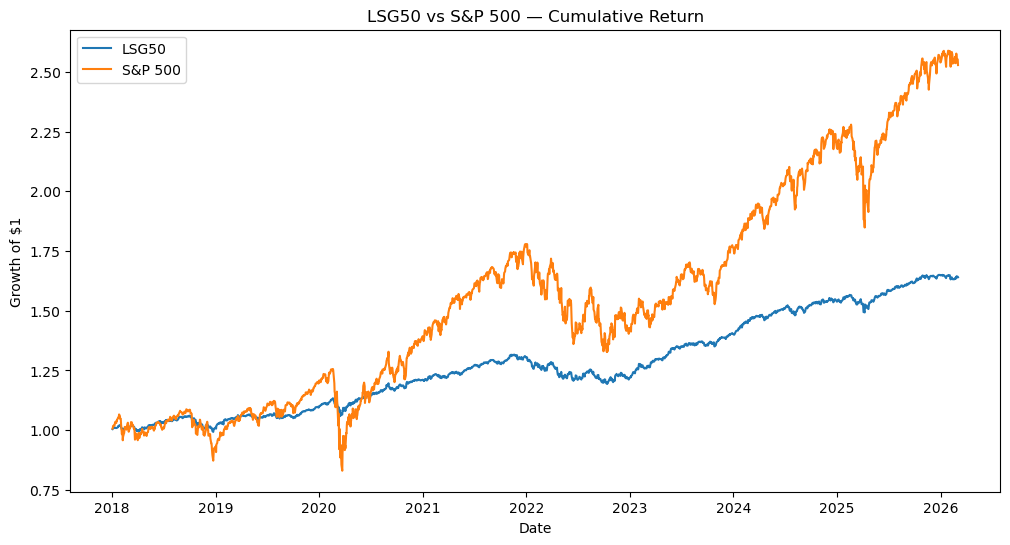

In [21]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_cum, label="LSG50")
plt.plot(sp500_cum, label="S&P 500")

plt.title("LSG50 vs S&P 500 — Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.show()

In [22]:
portfolio_mean = portfolio_returns.mean() * 252
portfolio_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = portfolio_mean / portfolio_vol

print("Annual Return:", portfolio_mean)
print("Volatility:", portfolio_vol)
print("Sharpe Ratio:", sharpe)

Annual Return: 0.062183989905913194
Volatility: 0.052837466759278605
Sharpe Ratio: 1.1768919617061937


## Methodological Notes

The results presented in this backtest should be interpreted within the context of several methodological assumptions and limitations common in quantitative research.

### Portfolio Construction

The LSG50 index is constructed by selecting the **top 50 companies ranked by the proprietary CFO Index score**. Portfolio weights are assigned proportionally to the score, meaning companies with stronger financial characteristics receive a higher allocation.

Unlike traditional benchmarks such as the S&P 500, which are **market-cap weighted**, this methodology introduces a **fundamental weighting scheme** designed to emphasize companies with stronger financial quality.

### Rebalancing Assumption

For simplicity, the backtest assumes that portfolio weights remain constant over the analysis period. In a real-world implementation, the index would likely be **rebalanced periodically** (e.g., quarterly or annually) to incorporate updated financial data.

### Transaction Costs

This analysis does **not incorporate transaction costs, slippage, or liquidity constraints**. As a result, realized returns in a real-world implementation may differ from the theoretical performance shown here.

### Survivorship Bias

The universe of companies used in the analysis is derived from the S&P 500 constituents. If the universe only contains companies that currently exist in the index, the analysis may be affected by **survivorship bias**, potentially overstating historical performance.

### Data Source

Historical price data is retrieved using the **Yahoo Finance API (via the yfinance library)**. Prices are adjusted for corporate actions using the `auto_adjust=True` parameter.

### Benchmark Comparison

Performance is evaluated relative to the **S&P 500 index**, represented by the ticker `^GSPC`. The benchmark serves as a proxy for broad U.S. equity market performance.

## Conclusion

The LSG50 index demonstrates strong cumulative performance relative to the S&P 500 over the analyzed period.

While these results are promising, further research would be required to evaluate robustness across different market regimes, rebalance frequencies, and transaction cost assumptions.